<a href="https://colab.research.google.com/github/yadavrishikesh/Masterclass-V2-2026/blob/main/module1/code/AI_Foundation_Lab_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Foundations: Hands-On Lab Session

## Context
Instead of looking at tiny 5-row DataFrames, today we will analyze a **real-world dataset**: Student Performance from a Portuguese secondary school.

**Objective:** Predict student final grades (`G3`) based on their habits, demographics, and school life, moving from basic NumPy all the way to Neural Networks.

**Instructions:**
- Complete all `# TODO` sections.
- Discuss the "Discussion" questions with your group.

## Learning Outcomes
By the end of this lab you should be able to:
- Perform matrix operations using NumPy
- Explore datasets with Pandas
- Visualize relationships using Matplotlib and Seaborn
- Build preprocessing pipelines
- Train regression and classification models
- Evaluate models using RMSE, F1 and ROC-AUC
- Build a neural network using TensorFlow

---
# Part 0: Environment Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML Tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.compose import ColumnTransformer

# Deep Learning
import tensorflow as tf

# Settings
sns.set_theme(style="whitegrid")
np.random.seed(42)
tf.random.set_seed(42)
%matplotlib inline

---
# Part 1: NumPy Warm-up
*Before we touch Pandas, let's ensure our matrix math is solid.*

In [ ]:
# Simulating a batch of 3 students with 2 features: [Hours Studied, Sleep Hours]
X_batch = np.array([[4,8],[8,6],[2,9]])
weights = np.array([2.5,0.5])
bias = 5.0

predictions = (X_batch @ weights) + bias
print("Predictions:", predictions)

Predictions: [19.  28.  14.5]


---
# Part 2: Data Loading & Pandas Profiling
*We will use the Student Performance dataset. The data is separated by semicolons.*

In [ ]:
# URL for the dataset
url = "https://raw.githubusercontent.com/KunjalJethwani/StudentPerformance/refs/heads/main/student-mat.csv"

# TODO 2: Read the CSV into a DataFrame called `df`
# Hint: Check the pandas documentation for the `sep` argument.
df = pd.read_csv(url, sep=';')

In [ ]:
print(df.head(3))
print("\nShape:", df.shape)
print("\nInfo:")
df.info()

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob     Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home  teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home    other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home    other  ...   

  famrel freetime  goout  Dalc  Walc health absences G1 G2  G3  
0      4        3      4     1     1      3        6  5  6   6  
1      5        3      3     1     1      3        4  5  5   6  
2      4        3      2     2     3      3       10  7  8  10  

[3 rows x 33 columns]

Shape: (395, 33)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-n

In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### Feature Engineering
Let's create meaningful categories.

In [ ]:
df['Pass'] = (df['G3'] >= 10).astype(int)

df.groupby('Pass')['G3'].mean()

,G3
Pass,
0,5.384615
1,12.883019


---
# Part 3: Exploratory Data Analysis (Visualization)
*Don't just plot—interpret.*

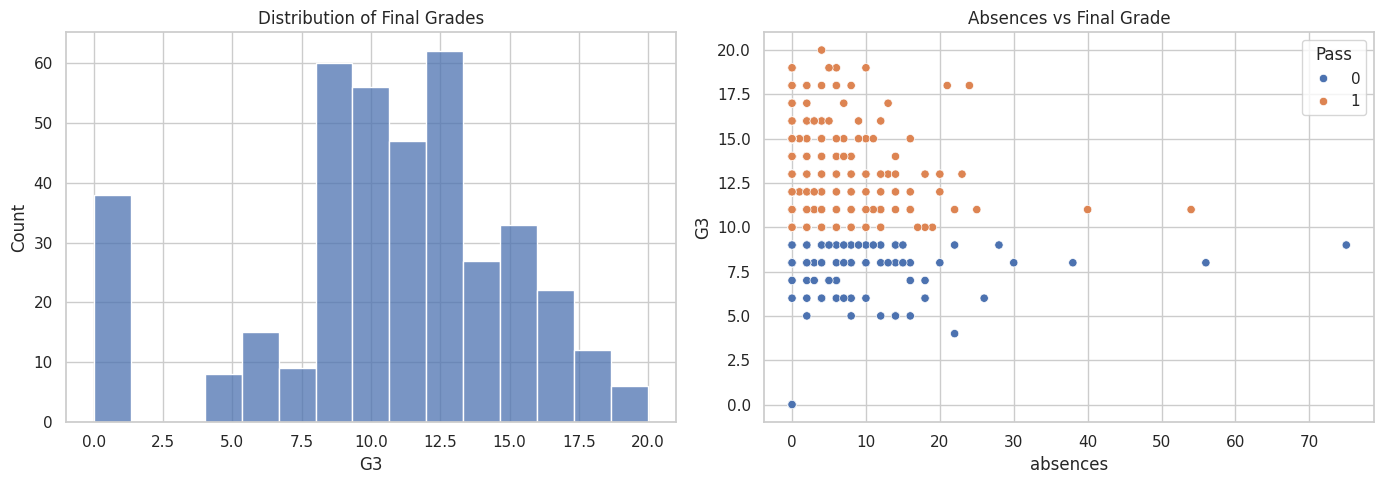

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df['G3'], bins=15, ax=axes[0])
axes[0].set_title("Distribution of Final Grades")

sns.scatterplot(data=df, x='absences', y='G3', hue='Pass', ax=axes[1])
axes[1].set_title("Absences vs Final Grade")

plt.tight_layout()
plt.show()

**Discussion:** Looking at the histogram, is the distribution of grades normal (bell curve)? What does this imply for modeling?

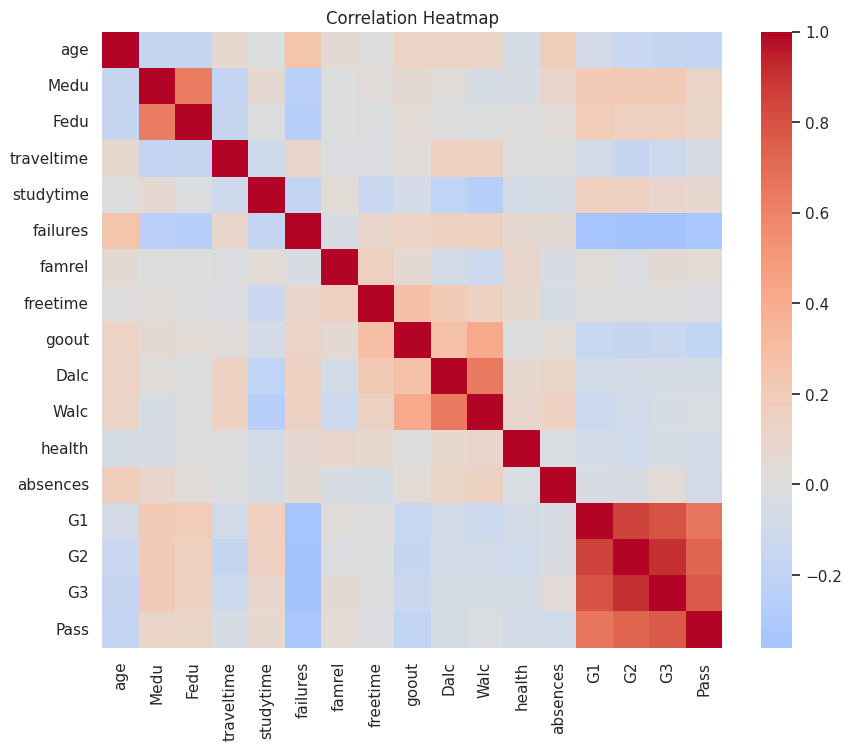

G3      1.000000
G2      0.904868
G1      0.801468
Pass    0.770042
Medu    0.217147
Name: G3, dtype: float64


In [ ]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

print(corr['G3'].sort_values(ascending=False).head())

### Additional Visualization
Let's look at how the final grade separates between passing and failing students.

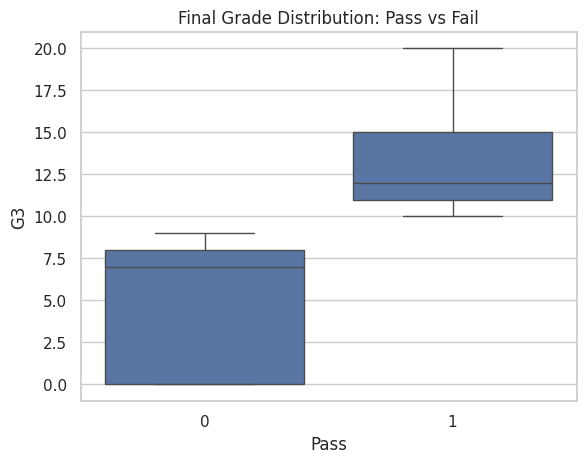

In [ ]:
sns.boxplot(x='Pass', y='G3', data=df)
plt.title("Final Grade Distribution: Pass vs Fail")
plt.show()

### Human Prediction Challenge
Before we let the machine learn, try to use your intuition.
Predict the final grade (G3) of a student with:
- studytime = 4
- absences = 2
- failures = 0
- schoolsup = yes
- famsup = no

*Write your guess here as a comment:*

In [ ]:
# My guess for G3 is:


---
# Part 4: Data Preprocessing Pipeline
*Real data has text categories. Models only take numbers.*

In [ ]:
# For simplicity, let's select a mix of numeric and categorical features
features = ['studytime', 'traveltime', 'age' ,'failures', 'Medu', 'schoolsup', 'famsup']
X = df[features]
y_reg = df['G3']       # Target for Regression
y_clf = df['Pass']     # Target for Classification

# TODO 9: Split the data into Training (80%) and Testing (20%) sets
# We do this twice to ensure the exact same rows are used for both regression and classification
X_train, X_test, y_reg_train, y_reg_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
_, _, y_clf_train, y_clf_test = train_test_split(X, y_clf, test_size=0.2, random_state=42)

In [ ]:
# We must scale numbers and one-hot encode text.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['studytime', 'traveltime', 'age', 'failures', 'Medu']),
        ('cat', OneHotEncoder(drop='first'), ['schoolsup', 'famsup'])
    ])

# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed shape:", X_train_processed.shape) # Should be (samples, 5 features)

Processed shape: (316, 7)


---
# Part 5: Supervised Learning - Regression
*Can we predict the exact grade?*

In [ ]:
reg_model = LinearRegression()
reg_model.fit(X_train_processed, y_reg_train)

LinearRegression()

In [ ]:
reg_preds = reg_model.predict(X_test_processed)

rmse = np.sqrt(mean_squared_error(y_reg_test, reg_preds))
r2 = r2_score(y_reg_test, reg_preds)

print("RMSE:", rmse)
print("R^2 Score:", r2)

RMSE: 4.335867186247347
R^2 Score: 0.08316503683194754


**Discussion:** An R^2 of ~0.1 is typical for this dataset using simple features. Human behavior is hard to predict! What features could we add to improve this?

### Baseline Model Exercise
Before celebrating our Linear Regression model, we must establish a baseline.
The dumbest model possible just predicts the average grade of the training set for every student.

In [ ]:
baseline_pred = np.repeat(y_reg_train.mean(), len(y_reg_test))
baseline_rmse = np.sqrt(mean_squared_error(y_reg_test, baseline_pred))

print(f"Baseline RMSE (Predicting Mean): {baseline_rmse:.2f}")
print(f"Linear Regression RMSE: {rmse:.2f}")

Baseline RMSE (Predicting Mean): 4.55
Linear Regression RMSE: 4.34


### Feature Importance Exercise
Since we used a linear model, we can look at the coefficients to see what the model learned.

In [ ]:
feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': reg_model.coef_
})#.sort_values('Coefficient', ascending=False)

coef_df

,Feature,Coefficient
0,num__studytime,0.510871
1,num__traveltime,-0.173285
2,num__age,-0.402720
3,num__failures,-1.465602
4,num__Medu,0.604330
5,cat__schoolsup_yes,-0.834100
6,cat__famsup_yes,-1.124571


---
# Part 6: Supervised Learning - Classification
*Can we predict if a student will Pass or Fail?*

In [ ]:
clf_model = LogisticRegression(max_iter=1000)
clf_model.fit(X_train_processed, y_clf_train)

LogisticRegression(max_iter=1000)

In [ ]:
clf_preds = clf_model.predict(X_test_processed)

print("Classification Report:")
print(classification_report(y_clf_test, clf_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_clf_test, clf_preds))

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.37      0.50        27
           1       0.74      0.94      0.83        52

    accuracy                           0.75        79
   macro avg       0.76      0.66      0.67        79
weighted avg       0.75      0.75      0.72        79


Confusion Matrix:
[[10 17]
 [ 3 49]]


In [ ]:
clf_probs = clf_model.predict_proba(X_test_processed)[:,1]
roc = roc_auc_score(y_clf_test, clf_probs)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.7172364672364673


### Evaluation Reflection
Look at your Confusion Matrix from TODO 14.
Why might **Recall** be more important than Accuracy for a school trying to identify at-risk students?

*Write your thoughts here as a comment:*

In [ ]:
# Recall is more important because...


---
# Part 7: TensorFlow Neural Network
*Let's see if a non-linear model beats Linear Regression.*

In [ ]:
nn_model = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation='relu', input_shape=(X_train_processed.shape[1],)),
    tf.keras.layers.Dense(2, activation='leaky_relu'),
    tf.keras.layers.Dense(1)
])

nn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

nn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_66 (Dense)                │ (None, 5)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ (None, 2)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55 (220.00 B)

 Trainable params: 55 (220.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = nn_model.fit(
    X_train_processed,
    y_reg_train,
    epochs=100,
    validation_split=0.2,
    verbose=0
)

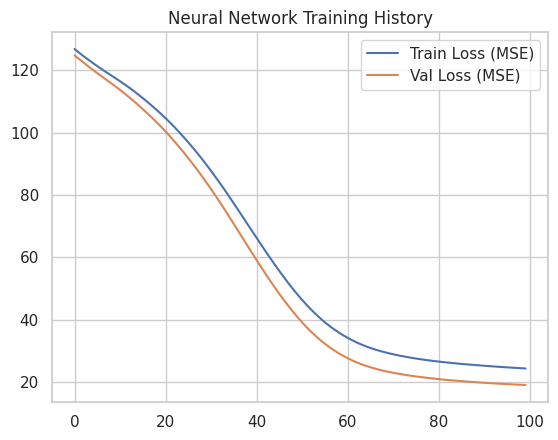

In [ ]:
# Plotting the training loss (Learning Curve)
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.legend()
plt.title("Neural Network Training History")
plt.show()

### Neural Network Reflection
Look at the plot above:
1. Is training loss decreasing?
2. Is validation loss decreasing?
3. Is there a gap between them? If yes, the model might be overfitting.

In [ ]:
nn_preds = nn_model.predict(X_test_processed, verbose=0).flatten()

nn_rmse = np.sqrt(mean_squared_error(y_reg_test, nn_preds))
print("NN RMSE:", nn_rmse)

NN RMSE: 4.329278124395468


---
# Part 8: Bonus Challenge

Neural networks are powerful because of hidden layers and non-linear activations.
Your task: Beat the Logistic Regression F1-Score using a Neural Network for the **Classification** task.

In [ ]:
clf_nn = tf.keras.Sequential([
    tf.keras.layers.Dense(5, activation='relu', input_shape=(X_train_processed.shape[1],)),
    tf.keras.layers.Dense(3, activation='relu'),
    tf.keras.layers.Dense(2, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

clf_nn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

clf_nn.fit(
    X_train_processed,
    y_clf_train,
    epochs=100,
    validation_split=0.2,
    verbose=0
)

nn_probs = clf_nn.predict(X_test_processed, verbose=0).flatten()
nn_preds = (nn_probs > 0.5).astype(int)

print("F1:", f1_score(y_clf_test, nn_preds))
print("ROC-AUC:", roc_auc_score(y_clf_test, nn_probs))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


F1: 0.7938931297709924
ROC-AUC: 0.7243589743589745
